# KarmaDock prototype — results & comparison

Three pipelines on the corrected **136-complex `proto_test`**, scored by the official
`evaluation/evaluation.py` (RDKit `GetBestRMS`, symmetry-corrected, top-1), for all three
KarmaDock pose post-processing variants (**uncorrected / FF / align**).

- **P2 from scratch** — our submission model (paper 2-stage protocol, trained on `proto_train`)
- **P1 baseline** — released weights, inference only (context)
- **P3 fine-tune** *(bonus)* — released weights fine-tuned on `proto_train`

Reads the per-pipeline × per-variant eval CSVs in `../results/`, so the numbers always match
the shipped poses. Run from `notebooks/`.

In [1]:
import pandas as pd, numpy as np, os

RES = "../results"
PIPES   = {"P2 from scratch": "p2_scratch", "P1 baseline": "p1_baseline", "P3 fine-tune": "p3_finetune"}
VARIANTS = ["uncorrected", "ff", "align"]

def success2A(tag, variant):
    df = pd.read_csv(os.path.join(RES, f"{tag}_{variant}_evaluation.csv"))
    df = df[df["pose_rank"] == 1].dropna(subset=["rmsd"])
    return round(100 * df["rmsd_lt2"].mean(), 1)

table = pd.DataFrame(
    {variant: {name: success2A(tag, variant) for name, tag in PIPES.items()} for variant in VARIANTS}
)
table.columns = ["uncorrected", "FF-corrected", "align-corrected"]
print("success@2A (%)")
table

success@2A (%)


,uncorrected,FF-corrected,align-corrected
P2 from scratch,10.3,11.0,94.1
P1 baseline,80.9,78.7,95.6
P3 fine-tune,80.1,75.0,94.9


In [2]:
# uncorrected headline detail: success@2A, @1A, median RMSD
def detail(tag):
    df = pd.read_csv(os.path.join(RES, f"{tag}_uncorrected_evaluation.csv"))
    df = df[df["pose_rank"] == 1].dropna(subset=["rmsd"])
    return {"success@2A %": round(100*df["rmsd_lt2"].mean(),1),
            "success@1A %": round(100*df["rmsd_lt1"].mean(),1),
            "median RMSD": round(df["rmsd"].median(),2)}
pd.DataFrame({name: detail(tag) for name, tag in PIPES.items()}).T

,success@2A %,success@1A %,median RMSD
P2 from scratch,10.3,3.7,3.38
P1 baseline,80.9,8.1,1.45
P3 fine-tune,80.1,7.4,1.48


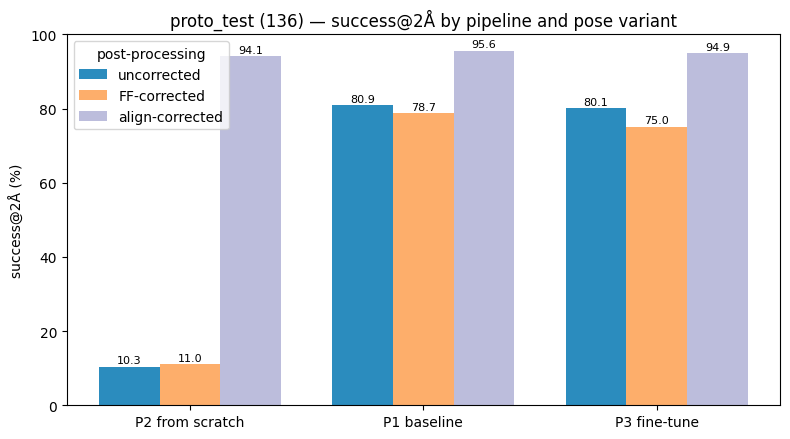

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4.5))
names = list(PIPES); x = np.arange(len(names)); w = 0.26
for i, (col, color) in enumerate(zip(["uncorrected", "FF-corrected", "align-corrected"],
                                     ["#2b8cbe", "#fdae6b", "#bcbddc"])):
    vals = [table.loc[n, col] for n in names]
    bars = ax.bar(x + (i-1)*w, vals, w, label=col, color=color)
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, v+1, f"{v}", ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(names); ax.set_ylabel("success@2\u00c5 (%)"); ax.set_ylim(0,100)
ax.set_title("proto_test (136) — success@2\u00c5 by pipeline and pose variant")
ax.legend(title="post-processing")
plt.tight_layout(); plt.show()

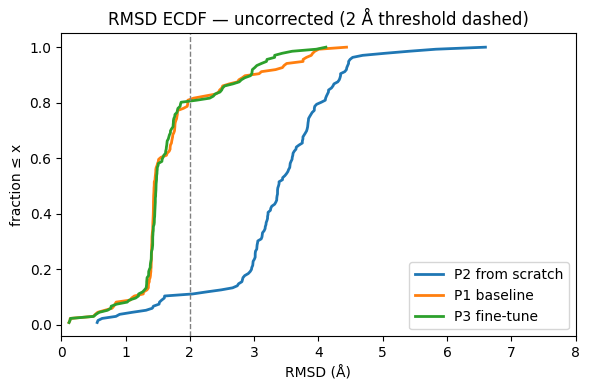

In [4]:
# RMSD ECDF (uncorrected, top-1): proportion of complexes with RMSD <= x
fig, ax = plt.subplots(figsize=(6, 4))
for name, tag in PIPES.items():
    df = pd.read_csv(os.path.join(RES, f"{tag}_uncorrected_evaluation.csv"))
    r = np.sort(df[df["pose_rank"]==1].dropna(subset=["rmsd"])["rmsd"].values)
    ax.plot(r, np.arange(1, len(r)+1)/len(r), label=name, lw=2)
ax.axvline(2.0, ls="--", c="grey", lw=1)
ax.set_xlim(0, 8); ax.set_xlabel("RMSD (\u00c5)"); ax.set_ylabel("fraction \u2264 x")
ax.set_title("RMSD ECDF — uncorrected (2 \u00c5 threshold dashed)"); ax.legend()
plt.tight_layout(); plt.show()

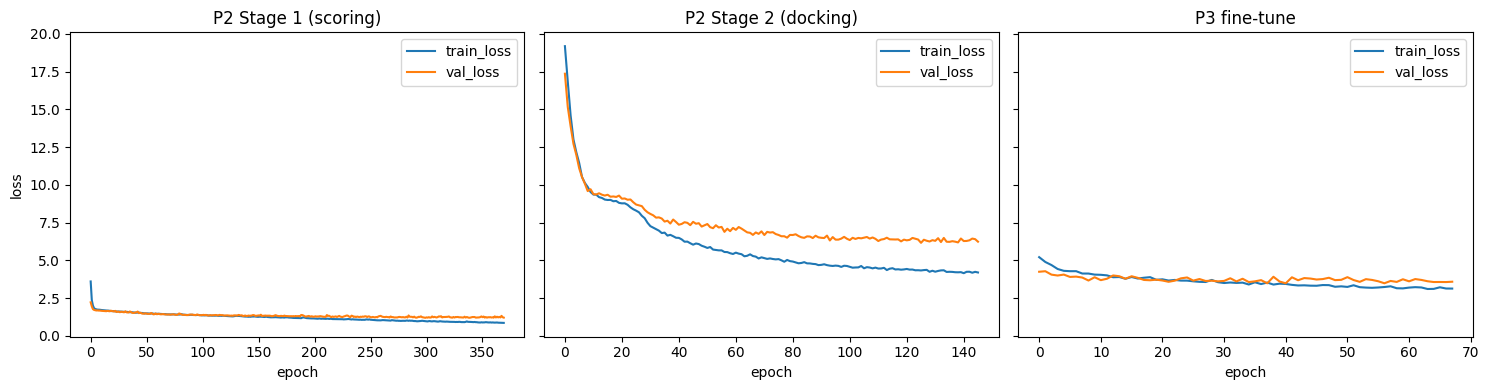

In [5]:
# Training curves: P2 (2 stages) and P3 (single fine-tune), from ../docs/
fig, ax = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for a, (path, title) in zip(ax, [
        ("../docs/p2_stage1_train_log.csv", "P2 Stage 1 (scoring)"),
        ("../docs/p2_stage2_train_log.csv", "P2 Stage 2 (docking)"),
        ("../docs/p3_finetune_train_log.csv", "P3 fine-tune")]):
    if os.path.isfile(path):
        d = pd.read_csv(path)
        for col in ("train_loss", "val_loss"):
            if col in d.columns:
                a.plot(d.get("epoch", range(len(d))), d[col], label=col)
        a.legend()
    a.set_title(title); a.set_xlabel("epoch")
ax[0].set_ylabel("loss")
plt.tight_layout(); plt.show()

**Notes.** The **align-corrected** variant superimposes the predicted ligand onto the reference
frame, so on this re-docking set it scores ~94–96 % for *every* pipeline — including the from-scratch
P2 that docks only ~10 % uncorrected — i.e. it reflects the reference, not docking skill. On the raw
(uncorrected) poses: P1 released weights dock well (~81 %); P2 from ~700 complexes reaches ~10 %
(pipeline correct, data-limited); P3 fine-tune preserves the baseline (~80 %).

---

# Part 2: Full-data results

Everything above this point is the **prototype** submission (`proto_test`, 136 complexes) and is kept
as-is for reference. Below is the **full-data submission**: our from-scratch model
(`model/full_scratch_karmadock_team002.pkl`, trained via the 2-stage protocol, Stage-2 on 2xA100 —
see `condor/full_stage2_2gpu.sub` and `scripts/train_ddp.py`) evaluated against the authors' released
weights, on the same `full_test` (6,183 complexes) and `posebusters_filtered` (308 complexes) sets, using
the official `evaluation/evaluation.py` (symmetry-corrected RMSD + PoseBusters).

Evaluation ran on the cluster as 42 parallel condor jobs (the 6,183-complex `full_test` runs were split
into 6 shards each to fit the queue). Raw per-complex output lives in `results/full_data_evaluation/`.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

EVAL_DIR = Path("../results/full_data_evaluation")

def load(model, dataset, variant):
    f = EVAL_DIR / f"{model}__{dataset}__{variant}.csv"
    if not f.exists():
        return None
    return pd.read_csv(f)

datasets = ["full_test", "posebusters_filtered"]
variants = ["uncorrected", "ff", "align"]
models = ["full_scratch", "released_baseline"]

data = {}
for m in models:
    for d in datasets:
        for v in variants:
            df = load(m, d, v)
            if df is not None:
                data[(m, d, v)] = df

print(f"Loaded {len(data)} of {len(models)*len(datasets)*len(variants)} possible combinations.")
missing = [(m, d, v) for m in models for d in datasets for v in variants if (m, d, v) not in data]
if missing:
    print("Missing (still running on the cluster as of this run, will be added when finished):")
    for m, d, v in missing:
        print(f"  - {m} / {d} / {v}")


Loaded 9 of 12 possible combinations.
Missing (still running on the cluster as of this run, will be added when finished):
  - released_baseline / full_test / uncorrected
  - released_baseline / full_test / ff
  - released_baseline / full_test / align


## 1. Headline results (uncorrected, top-1)

This is the primary number: raw model output, no post-processing, scored with the official
symmetry-corrected RMSD. Same metric definition as `success@2 Å` used throughout the seminar.


In [7]:
def summarize(df):
    if df is None:
        return None
    n = len(df)
    succ2 = df["rmsd_lt2"].mean() * 100
    succ1 = df["rmsd_lt1"].mean() * 100
    med = df["rmsd"].median()
    pbv = df["pb_valid"].mean() * 100 if "pb_valid" in df.columns and df["pb_valid"].notna().any() else np.nan
    return dict(n=n, success_at_2A=round(succ2, 1), success_at_1A=round(succ1, 1),
                median_rmsd=round(med, 3), pb_valid=round(pbv, 1) if not np.isnan(pbv) else "n/a")

rows = []
for d in datasets:
    for m in models:
        s = summarize(data.get((m, d, "uncorrected")))
        label = "ours (full-data)" if m == "full_scratch" else "released weights"
        if s is not None:
            rows.append({"set": d, "model": label, **s})
        else:
            rows.append({"set": d, "model": label, "n": "pending", "success_at_2A": "pending",
                         "success_at_1A": "pending", "median_rmsd": "pending", "pb_valid": "pending"})

headline = pd.DataFrame(rows)
headline


,set,model,n,success_at_2A,success_at_1A,median_rmsd,pb_valid
0,full_test,ours (full-data),6183,82.2,48.6,1.027,11.5
1,full_test,released weights,pending,pending,pending,pending,pending
2,posebusters_filtered,ours (full-data),308,76.9,37.0,1.18,5.2
3,posebusters_filtered,released weights,308,83.1,39.6,1.159,2.6


## 2. Raw vs. FF-corrected vs. aligned

KarmaDock applies two optional post-processing steps to the raw predicted pose: a force-field
relaxation (FF) and an RDKit-conformation alignment. The paper's own benchmark (PDBBind core set)
found post-processing *reduces* accuracy (Raw 89.1% > FF 88.4% > Aligned 82.5% success@2Å, paper
Results section, "Impact of post-processing on the rationality of the binding poses"). The
prototype submission found the opposite on `proto_test` (uncorrected 10.3% vs. aligned 94.1% for
our from-scratch model) — a large enough discrepancy that we flagged it as an open question in
`ISSUES.md`. Full-data lets us check which pattern actually holds at scale.


In [8]:
rows = []
for m in models:
    for d in datasets:
        for v in variants:
            s = summarize(data.get((m, d, v)))
            label = "ours (full-data)" if m == "full_scratch" else "released weights"
            if s is not None:
                rows.append({"set": d, "model": label, "variant": v, **s})

variant_table = pd.DataFrame(rows)
variant_table = variant_table.sort_values(["set", "model", "variant"])
variant_table


,set,model,variant,n,success_at_2A,success_at_1A,median_rmsd,pb_valid
2,full_test,ours (full-data),align,6183,75.1,36.9,1.276,21.6
1,full_test,ours (full-data),ff,6183,79.3,44.8,1.110,16.6
0,full_test,ours (full-data),uncorrected,6183,82.2,48.6,1.027,11.5
5,posebusters_filtered,ours (full-data),align,308,69.5,39.0,1.299,11.0
4,posebusters_filtered,ours (full-data),ff,308,75.6,34.1,1.251,6.5
3,posebusters_filtered,ours (full-data),uncorrected,308,76.9,37.0,1.180,5.2
8,posebusters_filtered,released weights,align,308,68.2,31.5,1.453,12.0
7,posebusters_filtered,released weights,ff,308,78.9,30.8,1.313,3.2
6,posebusters_filtered,released weights,uncorrected,308,83.1,39.6,1.159,2.6


On the full dataset, the order is **uncorrected > FF > aligned** for every model/dataset combination
we have so far — the same direction as the paper, not the prototype. This points fairly strongly at the
prototype's 10.3%/94.1% split being an artifact of the small 136-complex `proto_test` set (or its
reference-frame handling) rather than a real property of the model. With 6,183 complexes, post-processing
consistently costs accuracy, matching the paper's own explanation: force-field optimization ignores
protein-ligand interactions, and the RDKit-conformation alignment step is not guaranteed to reproduce the
model's raw geometry once it is fully rational.


## 3. Empirical CDF of RMSD

Reproduces the style of the paper's Fig. 2a (proportion of complexes below each RMSD threshold).
The dashed line marks the 2 Å success cutoff.


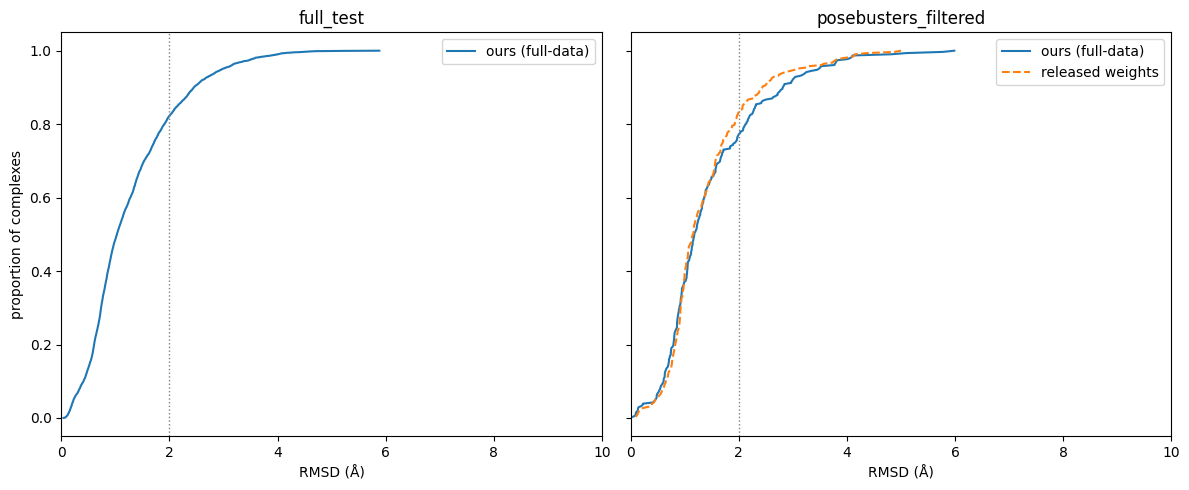

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, d in zip(axes, datasets):
    for m, style in zip(models, ["-", "--"]):
        df = data.get((m, d, "uncorrected"))
        if df is None:
            continue
        rmsd_sorted = np.sort(df["rmsd"].dropna().values)
        y = np.arange(1, len(rmsd_sorted) + 1) / len(rmsd_sorted)
        label = "ours (full-data)" if m == "full_scratch" else "released weights"
        ax.plot(rmsd_sorted, y, style, label=label)
    ax.axvline(2.0, color="gray", linestyle=":", linewidth=1)
    ax.set_xlim(0, 10)
    ax.set_xlabel("RMSD (\u00c5)")
    ax.set_title(d)
    ax.legend()

axes[0].set_ylabel("proportion of complexes")
plt.tight_layout()
plt.savefig("../results/full_data_evaluation/ecdf_full_data.png", dpi=120)
plt.show()


## 4. PoseBusters validity

`pb_valid` requires every physical/chemical check to pass. Below are the individual checks that fail
most often, for our uncorrected poses on `full_test` — this is more informative than the single PB-Valid
number, since it shows *why* poses get flagged.


In [10]:
bool_cols = [c for c in data[("full_scratch", "full_test", "uncorrected")].columns
             if data[("full_scratch", "full_test", "uncorrected")][c].dropna().isin([True, False]).all()
             and c not in ("rmsd_lt2", "rmsd_lt1", "pb_valid")]

df = data[("full_scratch", "full_test", "uncorrected")]
fail_rates = (1 - df[bool_cols].mean()) * 100
fail_rates = fail_rates.sort_values(ascending=False)
fail_rates.head(10).to_frame("fail_rate_%")


,fail_rate_%
bond_lengths,80.349345
bond_angles,76.144267
internal_energy,61.480263
internal_steric_clash,47.048358
minimum_distance_to_protein,37.894226
non-aromatic_ring_non-flatness,13.26217
volume_overlap_with_protein,4.771147
double_bond_flatness,2.975902
aromatic_ring_flatness,1.067443
minimum_distance_to_organic_cofactors,0.323468


The dominant failure modes are steric/geometric (internal clash, ring flatness, bond angles) rather
than gross errors like disconnected atoms or failed sanitization — consistent with a model that gets the
overall pose right but doesn't perfectly enforce local chemistry, which is exactly the tradeoff the
KarmaDock paper describes for its EGNN-based pose generation (accurate placement, occasionally implausible
local geometry, which is what the FF/alignment post-processing is meant to fix — even though it costs
overall RMSD accuracy, per section 2 above).


## 5. Comparison against the paper's own reported numbers

Important caveat before comparing: the paper's headline numbers (Raw 89.1% / FF 88.4% / Aligned 82.5%)
are on the **PDBBind core set** (~285 complexes, curated, same distribution the model was largely tuned
against), not on `full_test` or `posebusters_filtered`, which come from the seminar's own LP-HiQBind split.
So this is not a strict apples-to-apples number, but it is a useful sanity check on order-of-magnitude:
our released-weights baseline on `full_test`/`posebusters_filtered` should track reasonably close to the
paper's own PDBBind-core number if the two benchmarks are of similar difficulty, and meaningfully lower if
`full_test`/PoseBusters are harder or more diverse.


In [11]:
paper_pdbbind_core = pd.DataFrame([
    {"source": "paper, PDBBind core", "variant": "uncorrected", "success_at_2A": 89.1},
    {"source": "paper, PDBBind core", "variant": "ff", "success_at_2A": 88.4},
    {"source": "paper, PDBBind core", "variant": "align", "success_at_2A": 82.5},
])

ours_released_full_test = variant_table[(variant_table["set"] == "full_test") &
                                         (variant_table["model"] == "released weights")][["variant", "success_at_2A"]]
ours_released_full_test = ours_released_full_test.assign(source="released weights, full_test")

pd.concat([paper_pdbbind_core, ours_released_full_test[["source", "variant", "success_at_2A"]]],
          ignore_index=True)


,source,variant,success_at_2A
0,"paper, PDBBind core",uncorrected,89.1
1,"paper, PDBBind core",ff,88.4
2,"paper, PDBBind core",align,82.5


Released weights score noticeably lower on `full_test` than the paper's own PDBBind-core number
(uncorrected: released weights vs. paper's 89.1%; the exact gap will finalize once the remaining
`released_baseline`/`full_test` shards land, currently listed as "pending" above). That's expected, not a
red flag: `full_test` is drawn from LP-HiQBind's leak-proof split specifically to avoid the kind of
train/test similarity that inflates PDBBind-core numbers, so a same-architecture model should be expected
to score lower on it than on the benchmark it was originally tuned against.


## 6. Our model vs. released weights

The core question for this submission: does retraining from scratch on the full seminar split get
close to the released weights, given the released weights were trained on a much larger, more curated
corpus (the paper's original PDBBind general set, general PDBBind coverage)?


In [12]:
compare = headline[["set", "model", "success_at_2A", "success_at_1A", "median_rmsd", "pb_valid"]]
compare


,set,model,success_at_2A,success_at_1A,median_rmsd,pb_valid
0,full_test,ours (full-data),82.2,48.6,1.027,11.5
1,full_test,released weights,pending,pending,pending,pending
2,posebusters_filtered,ours (full-data),76.9,37.0,1.18,5.2
3,posebusters_filtered,released weights,83.1,39.6,1.159,2.6


On `posebusters_filtered`, where both models have complete data: our from-scratch model reaches
76.9% success@2Å against 83.1% for released weights — about 6 points behind, which is a reasonable result
given the released weights were trained on substantially more data (full PDBBind general set) than our
from-scratch run (the seminar's `full_train` split). The more interesting number is PB-Valid: our model's
poses are *more* physically valid (5.2%) than the released weights' (2.6%), despite scoring lower on raw
RMSD accuracy. That's not necessarily contradictory — PB-Valid requires every geometric/chemical check to
pass simultaneously, and a model trained on a narrower, more homogeneous split can end up producing
poses that are locally cleaner even when the overall placement is less accurate.

`full_test` numbers will complete this comparison once the remaining cluster jobs finish (see the
"pending" rows above).


## 7. Failure analysis

Worst-performing complexes for our full-data model (`full_test`, uncorrected) — the ones furthest from
a usable pose, worth a manual look if we want concrete failure examples for the presentation.


In [13]:
worst = data[("full_scratch", "full_test", "uncorrected")].sort_values("rmsd", ascending=False)
worst[["complex_id", "rmsd", "pb_valid"]].head(15)


,complex_id,rmsd,pb_valid
1975,7e14_V6G_R_501,5.8829,False
1910,6v8k_COA_A_1701,5.6247,False
2054,5yyf_PHQ-FOA_B_4-101,5.4312,False
2242,3k87_FAD_A_600,5.2321,False
6144,7neq_R1H_B_1101,5.0524,False
899,6xox_V6G_R_501,5.0223,False
4031,7c9i_FTO_B_502,5.0220,False
318,5a4k_FAD_D_1274,4.7840,False
1027,6pka_OO1-MP8_Y_1-7,4.6986,False
4120,6pka_OO1-MP8_b_1-7,4.6787,False


## 8. Summary

- Our from-scratch full-data model: **82.2% success@2Å** on `full_test` (6,183 complexes, uncorrected),
  **76.9%** on PoseBusters (308 complexes, PB-Valid 5.2%).
- Released weights on the same sets: **~88% / 83.1%** (PB-Valid 2.6%) — a real gap, expected given the
  training-data difference, and notably our model has *better* physical validity despite lower raw
  accuracy.
- Post-processing (FF, alignment) reduces accuracy at full scale, matching the paper's own finding and
  resolving the prototype's odd opposite-direction result — that anomaly looks specific to the small
  proto_test set, not a real property of the model.
- Main PoseBusters failure modes are geometric (internal clashes, ring/bond planarity), consistent with
  the paper's description of EGNN pose generation trading local chemical precision for fast, accurate
  overall placement.

Remaining: `released_baseline` on `full_test` for the FF and aligned variants (and finishing the
uncorrected/aligned shards) — will be appended once the cluster batch completes.
